- **Proyecto:** Predicción de ingresos y sistema de recomendación de trayectorias socioeconómicas.
- **Dataset:** Adult Income Dataset (UCI Machine Learning Repository + Oficina del Censo de EE.UU.)
- **Objetivo:** Predecir si una persona ganará más o menos de 50.000 USD al año y recomendar estrategias para superar ese umbral.

In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from scipy.spatial.distance import cosine

print("Librerías importadas.")

Librerías importadas.


**1. Carga del dataset**

In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(url)
print("Dataset cargado.")

Dataset cargado.


In [4]:
# Limpiar los nombres de las de columnas (eliminar espacios)
df.columns = df.columns.str.strip()

print(f"\nDimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 32,561 filas × 15 columnas


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [13]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [7]:
# Renombrar las columnas
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education.num',
    'marital.status', 'occupation', 'relationship', 'race', 'sex',
    'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income'
]

if df.shape[1] == 15 and df.columns[0] in ['0', 'age', '39']:
    df.columns = column_names
    print("Columnas renombradas.")

Columnas renombradas.


In [8]:
# Limpiar espacios en valores de tipo string
try:
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
except AttributeError:
    df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

print("Espacios limpiados.")

Espacios limpiados.


In [9]:
print("\nEstadísticas descriptivas:")
df.describe(include='all')


Estadísticas descriptivas:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


**2. Exploración de datos (EDA)**

In [ ]:
# Todos los valores faltantes del dataframe
df.isna().sum().sum()

np.int64(0)

In [ ]:
# Cuento los valores nulos para cada columna
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [24]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [21]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64

In [ ]:
# Posibles datos categóricos
df.select_dtypes(include=['object']).columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [20]:
# Distribución de la variable objetivo
print("Distribución de ingresos:")
print(df['income'].value_counts())
print(f"\nProporción >50K: {(df['income'].str.contains('>50K')).mean():.2%}")

Distribución de ingresos:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proporción >50K: 24.08%


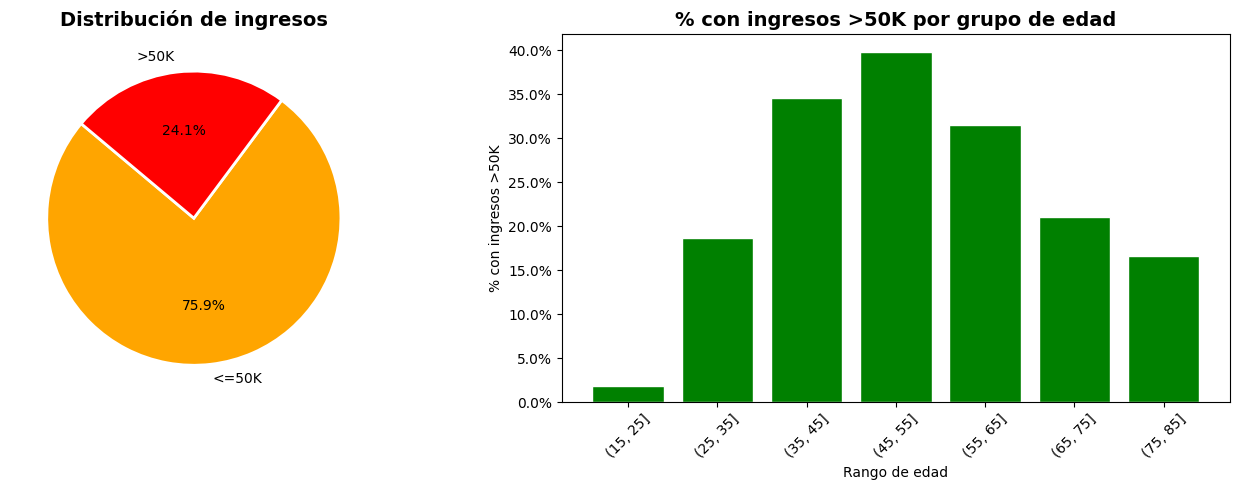

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['income'].value_counts()
axes[0].pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=['orange', 'red'], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribución de ingresos', fontsize=14, fontweight='bold')

# Bar chart por edad
df['income_bin'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)
age_income = df.groupby(pd.cut(df['age'], bins=range(15, 95, 10)))['income_bin'].mean().reset_index()
axes[1].bar(
    [str(x) for x in age_income['age']],
    age_income['income_bin'] * 100,
    color='green'[:len(age_income)], edgecolor='white'
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('% con ingresos >50K por grupo de edad', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rango de edad')
axes[1].set_ylabel('% con ingresos >50K')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ValueError: 'facecolor' or 'color' argument must be a valid color or sequence of colors.

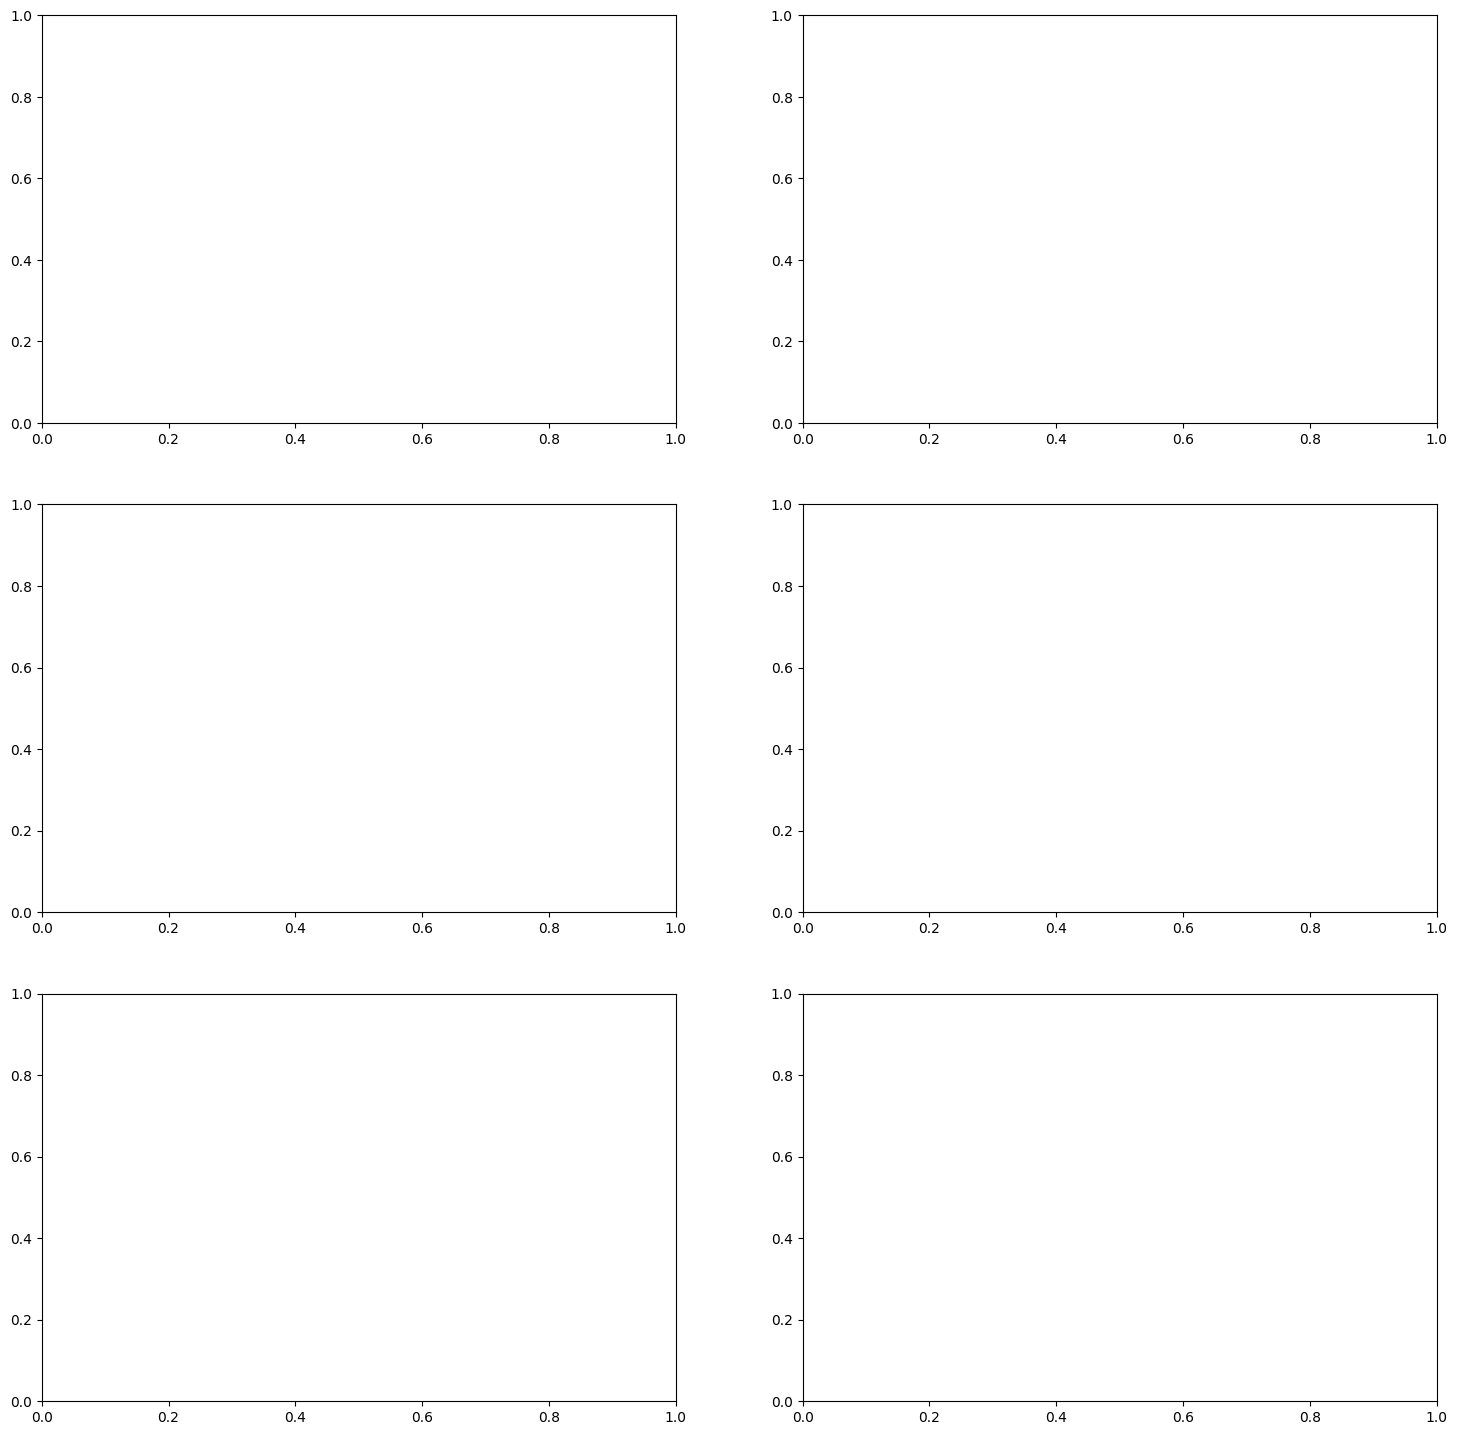

In [28]:
# Variables categóricas clave
cat_vars = ['education', 'occupation', 'marital.status', 'sex', 'race', 'workclass']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = df.groupby(var)['income_bin'].mean().sort_values(ascending=False).index
    ax = axes[i]
    
    grouped = df.groupby(var)['income_bin'].mean().reindex(order).reset_index()
    bars = ax.barh(
        grouped[var], grouped['income_bin'] * 100,
        color=['steelblue'[j % len('steelblue')] for j in range(len(grouped))],
    edgecolor='white'
)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'% >50K por {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% con ingresos >50K')
    ax.axvline(df['income_bin'].mean() * 100, color='red', linestyle='--', alpha=0.6, label='Promedio')
    ax.legend(fontsize=9)

plt.suptitle('Impacto de las variables socioeconómicas en ingresos >50K', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()